In [1]:
!pip install FastAPI -q
!pip install uvicorn -q
!pip install torch
!pip install python-multipart
!pip install fastapi nest-asyncio pyngrok uvicorn
!pip install torchvision

   ---------------------------------------- 0.0/199.4 MB ? eta -:--:--
   - -------------------------------------- 5.5/199.4 MB 30.5 MB/s eta 0:00:07
   -- ------------------------------------- 12.1/199.4 MB 30.2 MB/s eta 0:00:07
   ----- ---------------------------------- 28.3/199.4 MB 46.0 MB/s eta 0:00:04
   ------- -------------------------------- 36.7/199.4 MB 50.7 MB/s eta 0:00:04
   ------- -------------------------------- 38.3/199.4 MB 37.4 MB/s eta 0:00:05
   -------- ------------------------------- 41.7/199.4 MB 34.0 MB/s eta 0:00:05
   ---------- ----------------------------- 54.3/199.4 MB 38.0 MB/s eta 0:00:04
   ------------ --------------------------- 64.2/199.4 MB 40.1 MB/s eta 0:00:04
   ------------- -------------------------- 66.3/199.4 MB 36.1 MB/s eta 0:00:04
   --------------- ------------------------ 76.8/199.4 MB 37.1 MB/s eta 0:00:04
   ---------------- ----------------------- 84.1/199.4 MB 37.5 MB/s eta 0:00:04
   ------------------ --------------------- 90.4/1

# 1.fastapi

In [1]:
import os
import torch
import uvicorn
import nest_asyncio

from PIL import Image, ImageDraw, ImageFont
from io import BytesIO
from pyngrok import ngrok
from torchvision import transforms
from fastapi import FastAPI, File, UploadFile, Form
import matplotlib.pyplot as plt
import cv2
import numpy as np

from fastapi.responses import HTMLResponse, RedirectResponse, StreamingResponse, JSONResponse
%matplotlib inline

def y_line1(x):
    return 2.865591 * int(x) -1388.118279
def y_line2(x):
    return 2.299007 * int(x) -1920.242990

In [2]:
os.chdir("opencv/opencv_study/comento")
os.getcwd()

'C:\\Users\\User.DESKTOP-5C3VHRV\\opencv\\opencv_study\\comento'

In [2]:
app = FastAPI()

model = torch.hub.load('C:/Users/User.DESKTOP-5C3VHRV/opencv/opencv_study/comento/yolov5', 'custom', path='C:/Users/User.DESKTOP-5C3VHRV/opencv/opencv_study/comento/best.pt', source='local')
model.conf=0.82

authtoken = '2mMUpg7qqiMmnj7D4SbXS6TGU7p_5LUdbgqrMN5TDwrLPs3Bk'
ngrok.set_auth_token(authtoken)

YOLOv5  v7.0-368-gb163ff8d Python-3.10.14 torch-2.4.1+cpu CPU

Fusing layers... 
YOLOv5s summary: 157 layers, 7012822 parameters, 0 gradients, 15.8 GFLOPs
Adding AutoShape... 


In [ ]:
@app.get("/", response_class=RedirectResponse)
async def root():
    return RedirectResponse(url="/upload")


@app.get("/upload", response_class=HTMLResponse)
async def upload_file():
    return """
    <html>
        <head>
            <title>Upload Image</title>
        </head>
        <body>
            <h1>Upload an image for detection</h1>
            <form action="/detect" enctype="multipart/form-data" method="post">
                <input name="file" type="file"><br>
                <input type="radio" id="coordinates" name="option" value="coordinates" checked>
                <label for="coordinates">Bounding Box Coordinates and Info</label><br>
                <input type="radio" id="image" name="option" value="image">
                <label for="image">Bounding Box Image</label><br><br>
                <input type="submit" value="Upload">
            </form>
        </body>
    </html>
    """
   
@app.post('/detect')
async def detect_api(file: UploadFile = File(...), option: str = Form(...)):

    # 비동기적으로 파일 읽기
    image_bytes = await file.read()

    try:
        img = Image.open(BytesIO(image_bytes))
        img= img.resize((1920,1040))
        
        result = model(img,size=1920)
        results= result.pandas().xyxy[0]

        if option == "image":
            #img=boundingbox(img,results)
            img=Image.fromarray(result.render()[0])
        
            img_byte_arr = BytesIO()
            img.save(img_byte_arr, format='PNG')
            img_byte_arr.seek(0)

            return StreamingResponse(img_byte_arr, media_type="image/png")

        elif option == "coordinates":
            detections_list = []
            for index, row in results.iterrows():
                detections_list.append({
                    "x1": float(row['xmin']),
                    "y1": float(row['ymin']),
                    "x2": float(row['xmax']),
                    "y2": float(row['ymax']),
                    "confidence": float(row['confidence']),
                    "class": int(row['class'])
                })

            a,b,c,d=0,0,0,0
            for i in range(len(results.values)):
                data=results.values[i]
                x=(data[0]+data[2])/2
                y=(data[1]+data[3])/2
            
                if y> y_line1(x):
                    a+=1
                elif y> y_line2(x) and y< y_line1(x):
                    b+=1
                elif y< y_line2(x):
                    c+=1
                else:
                    d+=1
            detections_list.append({"도로상황" : f"동부간선도로 방향 {a}대, 중앙차선 {b}대, 수서ic방향 {c}대, 총 차량 {a+b+c+d}대"})
    
            return JSONResponse(content={"detections": detections_list})

    except Exception as e:
        return {"error": "이미지 처리 실패", "details": str(e)}

# ngrok 터널 설정
port = 8000
public_url = ngrok.connect(port)
print(f"Public URL: {public_url}")

# colab에서 비동기 실행 문제 해결
nest_asyncio.apply()

# FastAPI 서버 실행
port=8000
uvicorn.run(app, host="0.0.0.0", port=port)

INFO:     Started server process [40524]
INFO:     Waiting for application startup.
INFO:     Application startup complete.
INFO:     Uvicorn running on http://0.0.0.0:8000 (Press CTRL+C to quit)


Public URL: NgrokTunnel: "https://1c1e-125-128-53-206.ngrok-free.app" -> "http://localhost:8000"
INFO:     127.0.0.1:14326 - "GET / HTTP/1.1" 307 Temporary Redirect
INFO:     127.0.0.1:14326 - "GET /upload HTTP/1.1" 200 OK


C:\Users/User.DESKTOP-5C3VHRV/opencv/opencv_study/comento/yolov5\models\common.py:892: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with amp.autocast(autocast):


INFO:     127.0.0.1:14327 - "POST /detect HTTP/1.1" 200 OK


# 2.trial

C:\Users/User.DESKTOP-5C3VHRV/opencv/opencv_study/comento/yolov5\models\common.py:892: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with amp.autocast(autocast):


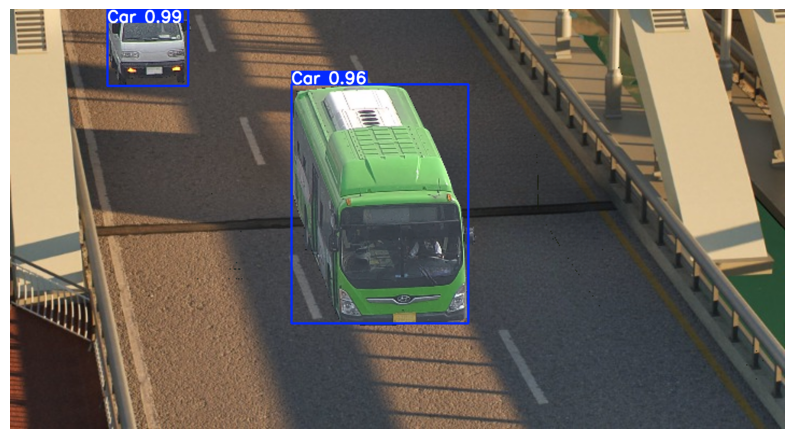

In [25]:
img = Image.open('C:/Users/User.DESKTOP-5C3VHRV/opencv/opencv_study/comento/newimage.png')
img=img.resize((1920,1040))
result = model(img,size=1920) #가장 긴 픽셀 기준으로 1920으로 맞추고 종횡비를 맞추어서 resize함 
results= result.pandas().xyxy[0]

result.render()[0]

# 추론 결과 확인하기
#print(results.pandas().xyxy[0])

# Save or display results

plt.figure(figsize=(10,6))
plt.imshow(result.render()[0])
plt.axis('off')
plt.show()

In [12]:
results

,xmin,ymin,xmax,ymax,confidence,class,name
0,90.629288,0.000000,164.814026,71.443359,0.986447,0,Car
1,262.408905,70.387833,426.451355,291.297729,0.972034,0,Car


In [27]:
a,b,c,d=0,0,0,0
for i in range(len(results.values)):
    data=results.values[i]
    x=(data[0]+data[2])/2
    y=(data[1]+data[3])/2
    
    if y> y_line1(x):
        a+=1
    elif y> y_line2(x) and y< y_line1(x):
        b+=1
    elif y< y_line2(x):
        c+=1
    else:
        d+=1
print(a,b,c,d)

1 1 0 0


In [ ]:
img = img.transpose(2, 0, 1)
img = torch.from_numpy(img).float()  # 텐서로 변환
img = img.unsqueeze(0)

In [ ]:
def boundingbox(img,results):
    font= ImageFont.truetype("arial.ttf",size=23)
    draw= ImageDraw.Draw(img)
    for i in range(len(results.values)):
        x1 , y1, x2, y2 = results.values[i][:4]
        clas = results.values[i][5]
        draw.rectangle([x1, y1, x2, y2], outline="red", width=3)
        draw.text((x1, y1-20), f"class: {results.values[i][6]}, Conf: {results.values[i][4]:.2f}", fill="red", font=font)
    return img

def y_line1(x):
    return 2.865591 * int(x) -1388.118279
def y_line2(x):
    return 2.299007 * int(x) -1920.242990

In [ ]:
!pip install numpy --upgrade

In [ ]:
!git clone https://github.com/ultralytics/yolov5
%cd yolov5
!pip install -r requirements.txt